In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afolu.assets.constants import LABEL_LIST
from afolu.assets.emissions import build_dataset, generate_model_objects

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\munch\__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
warnings.filterwarnings("ignore")

In [3]:
ZONE = "GUY+Georgetown"

In [4]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [5]:
transitions = pd.read_csv(
    out_path / "small" / "transition" / "cube" / f"{ZONE}.csv",
).set_index("time_period")

transition_mat = np.zeros((len(transitions), len(LABEL_LIST), len(LABEL_LIST)))
for idx, row in transitions.iterrows():
    data = (
        row.rename("value")
        .reset_index()
        .assign(
            index=lambda df: df["index"].str.replace("pij_lndu_", ""),
            start=lambda df: df["index"].str.split("_to_").str[0].str.strip(),
            end=lambda df: df["index"].str.split("_to_").str[1].str.strip(),
        )
        .drop(columns=["index"])
        .pivot_table(index="start", columns="end", values="value")
    )
    data = data.sort_index(axis=0)
    data = data.sort_index(axis=1)
    transition_mat[idx, :, :] = data.to_numpy()

In [6]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .transpose()
)
df_area.index = df_area.index.astype(int)

df_area = df_area[sorted(df_area.columns)]

df_area_frac = df_area.div(df_area.sum(axis=1), axis=0)

In [7]:
def get_area_coefficients(df_area: pd.DataFrame) -> dict[str, np.ndarray]:
    X = df_area.index.to_numpy().reshape(-1, 1)
    return {
        label: np.polyfit(X.flatten(), df_area[label].to_numpy(), 1)
        for label in df_area.columns
    }


def derive_coef(x: float, orig_coef: np.ndarray, scale: float) -> np.ndarray:
    new_slope = orig_coef[0] * scale
    new_intersect = np.polyval(orig_coef, x) - new_slope * x
    return np.array([new_slope, new_intersect])


def predict_scaled(x: float, orig_coef: np.ndarray, scale: float) -> float:
    coef = derive_coef(x[0], orig_coef, scale)
    return np.polyval(coef, x)

In [8]:
abs_coefficients = get_area_coefficients(df_area)
frac_coefficients = get_area_coefficients(df_area_frac)

In [ ]:
X = df_area_frac.index.to_numpy()
X_future = np.arange(X[-1], X[-1] + 20)

y_normal = np.zeros((len(X_future), len(LABEL_LIST)))
y_fast = np.zeros((len(X_future), len(LABEL_LIST)))
y_slow = np.zeros((len(X_future), len(LABEL_LIST)))

offset = 0.15

for i, label in enumerate(LABEL_LIST):
    coef = frac_coefficients[label]

    if (
        label in ["forests_primary", "forests_secondary", "forests_mangroves"]
        and coef[0] > 0
    ):
        fast_scale = 1 - offset
        slow_scale = 1 + offset
    else:
        fast_scale = 1 + offset
        slow_scale = 1 - offset

    y_normal[:, i] = predict_scaled(X_future, coef, 1.0)
    y_fast[:, i] = predict_scaled(X_future, coef, fast_scale)
    y_slow[:, i] = predict_scaled(X_future, coef, slow_scale)

settlement_idx = LABEL_LIST.index("settlements")
y_normal[:, settlement_idx] += 1 - y_normal.sum(axis=1)
y_fast[:, settlement_idx] += 1 - y_fast.sum(axis=1)
y_slow[:, settlement_idx] += 1 - y_slow.sum(axis=1)

In [ ]:
def adjust_and_predict(
    Q: np.ndarray,
    x0: np.ndarray,
    targets: dict[int, float],
) -> tuple[np.ndarray, np.ndarray]:
    costs = {key: 0 for key in range(len(LABEL_LIST)) if key not in targets}

    vec_infimum = np.array([-999.0])
    vec_supremum = np.array([999.0])

    _, _, model_afolu, *_ = generate_model_objects()
    _, _, xT, *_ = model_afolu.qadj_get_inputs(
        Q,
        x0,
        targets,
        vec_infimum,
        vec_supremum,
    )

    Q_adj = model_afolu.q_adjuster.solve(
        Q,
        x0,
        xT,
        vec_infimum,
        vec_supremum,
        model_afolu.flag_ignore_constraint,
        costs_x=costs,
    )
    x_future = x0 @ Q_adj
    return Q_adj, x_future


def predict_all(
    Q: np.ndarray,
    x: np.ndarray,
    target_arr: np.ndarray,
    nyears: int = 20,
) -> tuple[np.ndarray, np.ndarray]:
    Q_hist, y_hist = [], []

    for i in range(nyears):
        targets = {j: target_arr[i, j] for j in range(len(LABEL_LIST))}
        Q, x = adjust_and_predict(Q, x, targets)
        Q_hist.append(Q)
        y_hist.append(x)

    return np.array(Q_hist), np.array(y_hist)

In [70]:
Q = transition_mat[-1]
x = df_area_frac.iloc[-1].to_numpy()
Q_hist_fast, y_hist_fast = predict_all(Q, x, y_fast)
Q_hist_normal, y_hist_normal = predict_all(Q, x, y_normal)
Q_hist_slow, y_hist_slow = predict_all(Q, x, y_slow)

In [224]:
Qtemp = np.load("./Q.npy")
xtemp = np.load("./x.npy")
target_arr_temp = np.load("./target_arr.npy")

Q_hist_slow = np.load("./Q_hist.npy")
y_hist_slow = np.load("./y_hist.npy")

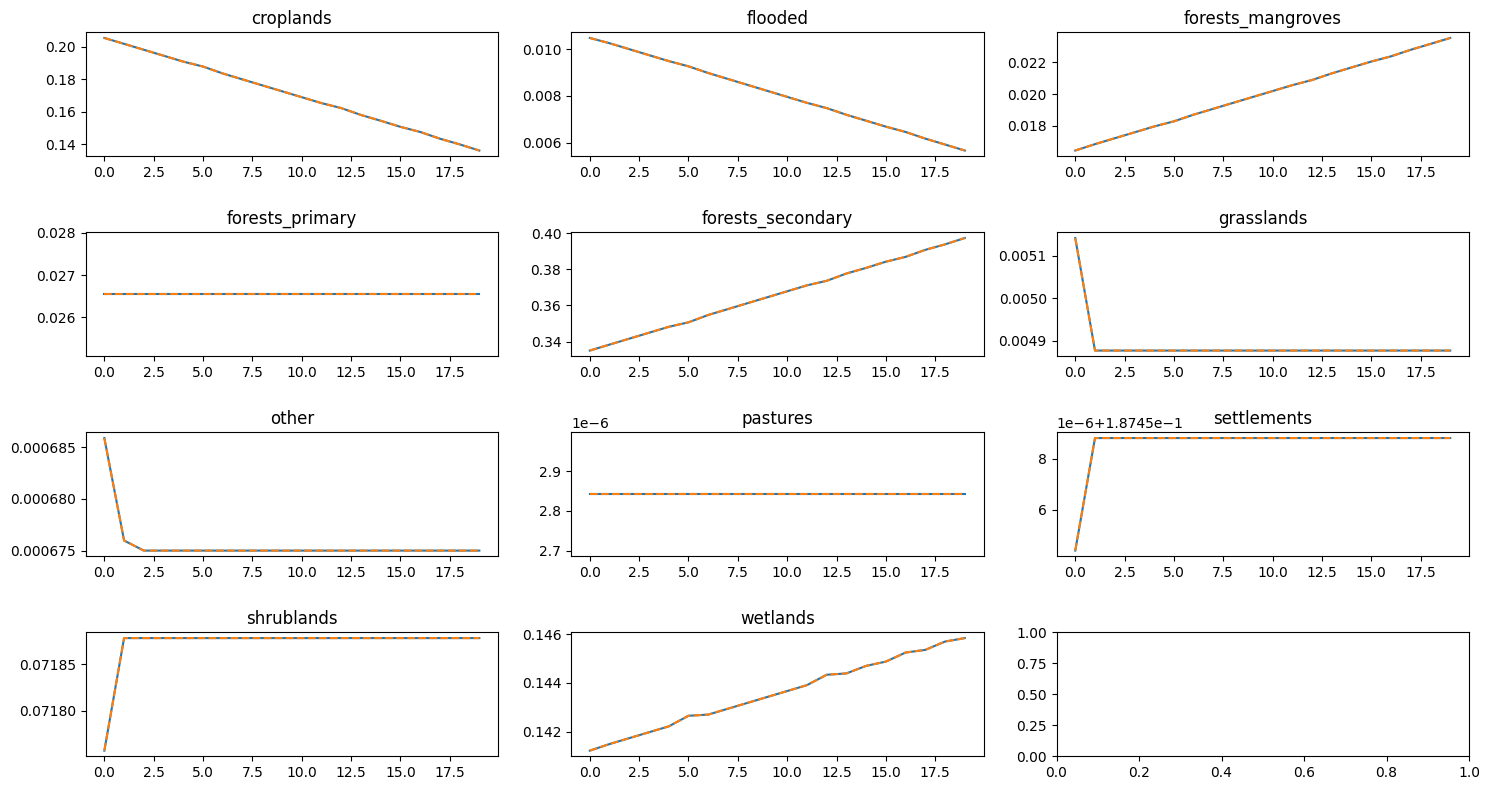

In [225]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))

for arr_1, arr_2, label, ax in zip(
    y_hist_slow.T,
    y_hist_temp.T,
    LABEL_LIST,
    axes.flatten(),
    strict=False,
):
    ax.plot(arr_1)
    ax.plot(arr_2, ls="--")
    ax.set_title(label)
fig.tight_layout()

In [226]:
start_time_period = df_area_frac.index[-1]
df_area_frac_pred = pd.DataFrame(
    y_hist_fast[1:],
    index=range(start_time_period + 1, start_time_period + 20),
    columns=LABEL_LIST,
)

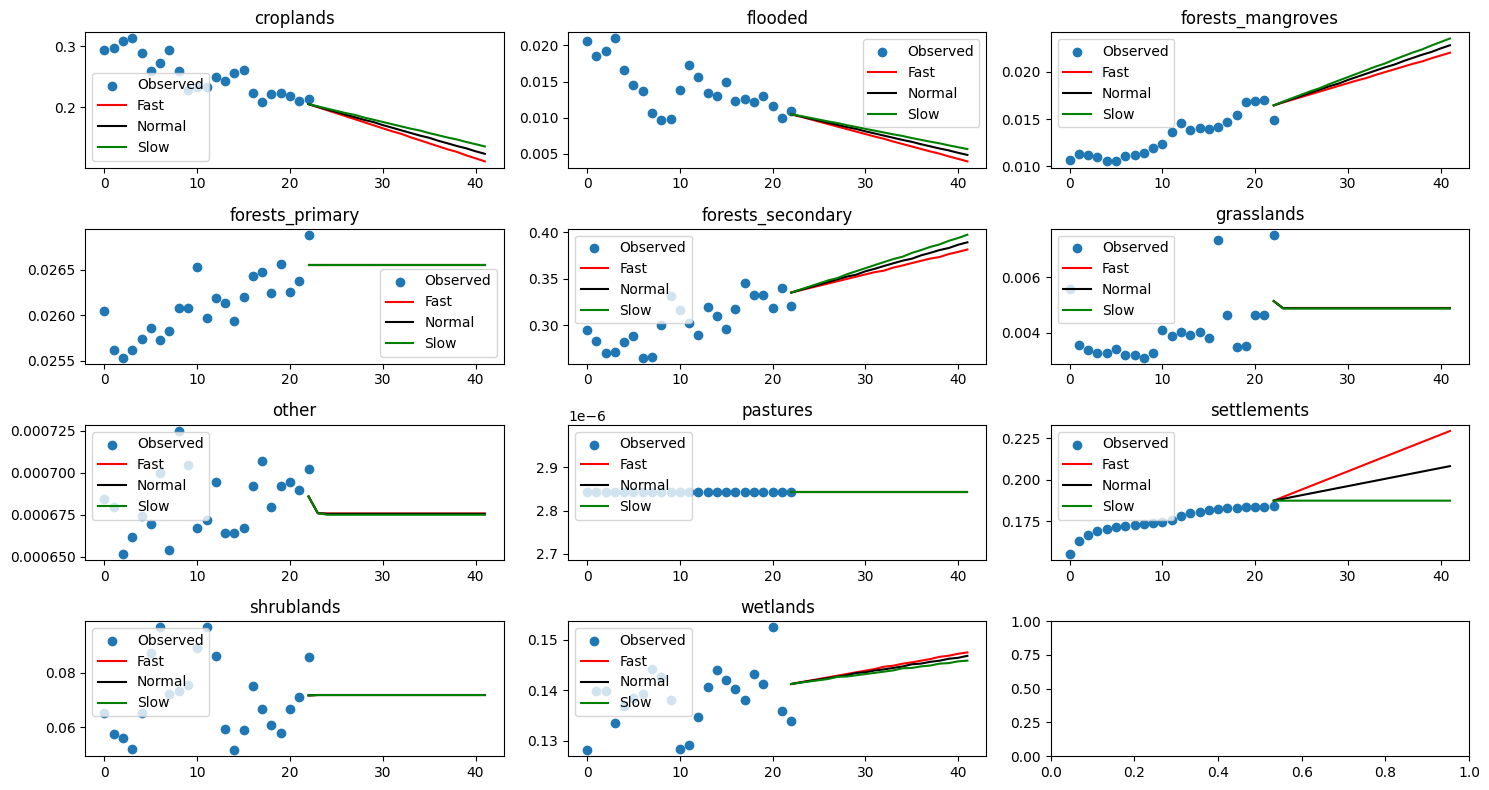

In [227]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
for i in range(len(LABEL_LIST)):
    ax = axes.flat[i]
    ax.scatter(X, df_area_frac[LABEL_LIST[i]], label="Observed")
    ax.plot(X_future, y_hist_fast[:, i], label="Fast", c="red")
    ax.plot(X_future, y_hist_normal[:, i], label="Normal", c="k")
    ax.plot(X_future, y_hist_slow[:, i], label="Slow", c="green")
    ax.set_title(LABEL_LIST[i])
    ax.legend()

fig.tight_layout()

In [642]:
def build_dataframes(
    df_transition_orig: pd.DataFrame,
    df_area_orig: pd.DataFrame,
    transition_pred: np.ndarray,
    area_pred: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_area = df_area_orig.copy()
    df_transition = df_transition_orig.copy()

    for row in area_pred:
        df_area.loc[df_area.index[-1] + 1] = row

    for row in transition_pred:
        df_transition.loc[df_transition.index[-1] + 1] = row.reshape(-1)

    df_area = df_area.T.reset_index()
    df_transition = df_transition.reset_index()

    return df_area, df_transition


def emissions_small(
    areas: pd.DataFrame,
    transitions: pd.DataFrame,
    *,
    iso: str,
) -> pd.DataFrame:
    # Initialize SISEPUEDE objects
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    temp = areas.set_index("label")

    areas_frac = temp.div(temp.sum(axis=0), axis=1).reset_index(names="label")

    # run model
    dict_ursa_data = {
        "areas": areas,
        "areas_frac": areas_frac,
        "transitions": transitions,
    }
    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")


def foo(dict_ursa_data: dict, *, iso: str) -> pd.DataFrame:
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")

In [643]:
Q_hist = {"fast": Q_hist_fast, "normal": Q_hist_normal, "slow": Q_hist_slow}

y_hist = {"fast": y_hist_fast, "normal": y_hist_normal, "slow": y_hist_slow}

In [644]:
out_map, total_area_map = {}, {}
for label in ["slow", "normal", "fast"]:
    Q = Q_hist[label]
    y = y_hist[label]
    total_area_frac, total_transition = build_dataframes(
        transitions,
        df_area_frac,
        Q,
        y,
    )

    total_area = (
        total_area_frac.set_index("label")
        .multiply(df_area.sum(axis=1).mean())
        .reset_index()
    )
    total_area_map[label] = total_area

    out_map[label] = emissions_small(
        total_area,
        total_transition,
        iso=ZONE.split("+")[0],
    )

In [645]:
areas_temp = pd.read_csv("./areas.csv")
areas_frac_temp = pd.read_csv("./areas_frac.csv")
transitions_temp = pd.read_csv("./transitions.csv")

areas_temp.columns = [int(c) if c.isdigit() else c for c in areas_temp.columns]
areas_frac_temp.columns = [
    int(c) if c.isdigit() else c for c in areas_frac_temp.columns
]

asd = foo(
    {
        "areas": areas_temp,
        "areas_frac": areas_frac_temp,
        "transitions": transitions_temp,
    },
    iso=ZONE.split("+")[0],
)

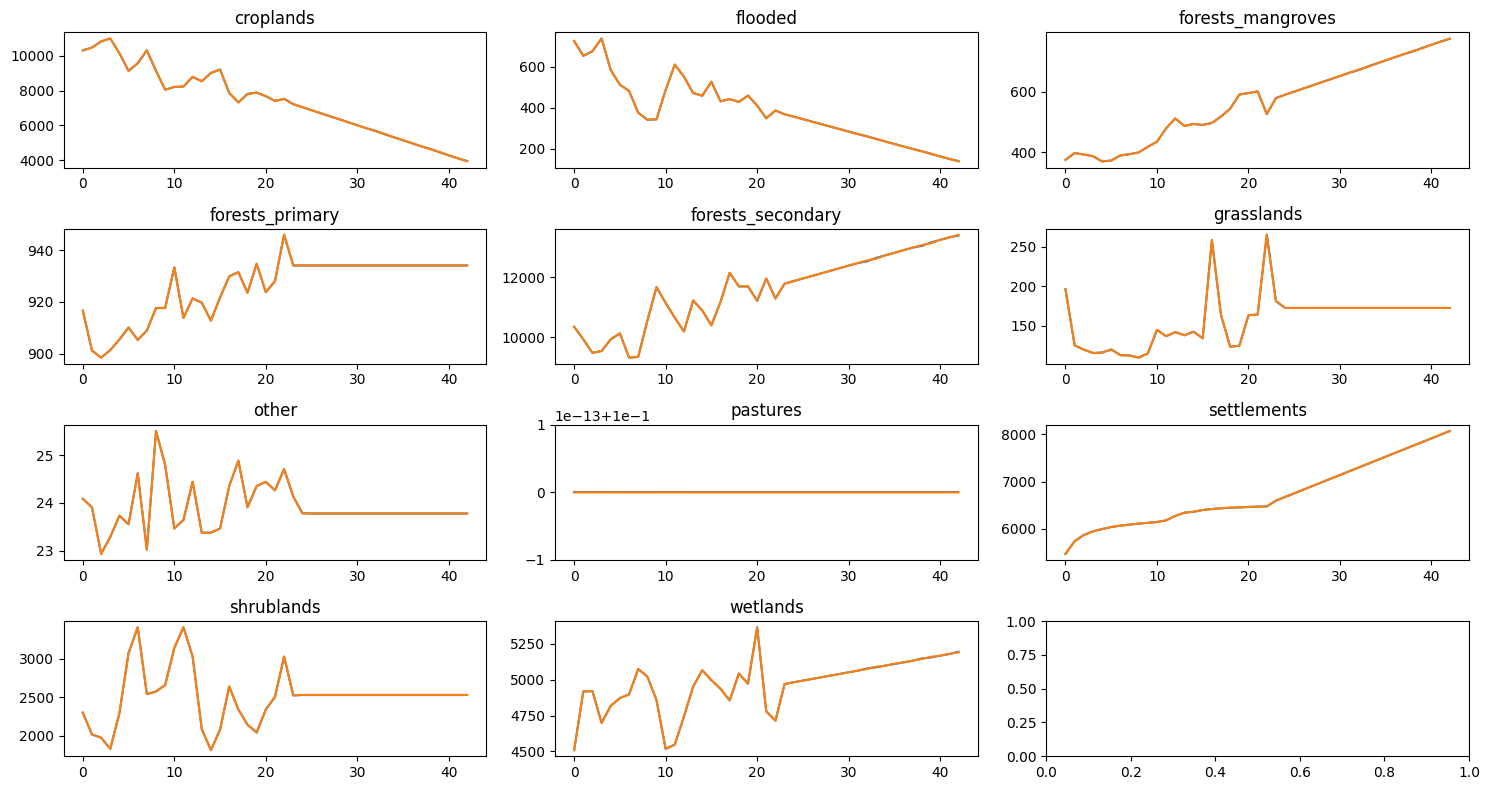

In [648]:
a = areas_temp.set_index("label")
b = total_area_map["fast"].set_index("label")

fig, axes = plt.subplots(4, 3, figsize=(15, 8))
for label, ax in zip(LABEL_LIST, axes.flatten(), strict=False):
    a.loc[label].plot(ax=ax)
    b.loc[label].plot(ax=ax, label="fast")
    ax.set_title(label)

fig.tight_layout()

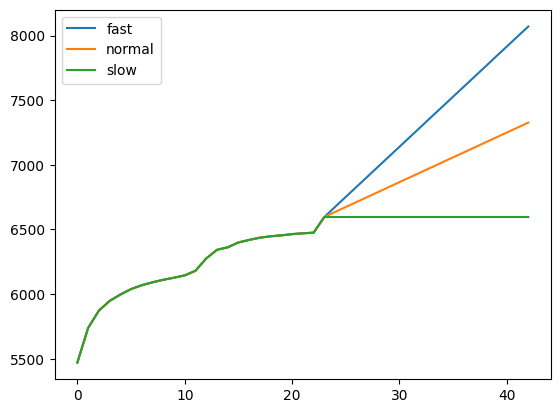

In [649]:
total_area_map["fast"].set_index("label").loc[["settlements"]].sum(axis=0).plot(
    label="fast",
)
total_area_map["normal"].set_index("label").loc[["settlements"]].sum(axis=0).plot(
    label="normal",
)
total_area_map["slow"].set_index("label").loc[["settlements"]].sum(axis=0).plot(
    label="slow",
)
plt.legend()

In [650]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

emission_columns = [
    "emission_co2e_subsector_total_frst",
    "emission_co2e_subsector_total_lndu",
    "emission_co2e_co2_soil_soc_mineral_soils",
    "emission_co2e_n2o_soil_mineral_soils",
    "emission_co2e_n2o_soil_organic_soils",
]

In [651]:
def load_emission_df(fpath: os.PathLike) -> pd.DataFrame:
    return (
        pd.read_csv(fpath).set_index("time_period")
        # .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
        # .rename(columns={"time_period": "year"})
        # .query("year <= 2035")
        # .set_index("year")
    )


df_emissions_fast = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "fast" / f"{ZONE}.csv",
)
df_emissions_normal = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "normal" / f"{ZONE}.csv",
)
df_emissions_slow = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "slow" / f"{ZONE}.csv",
)

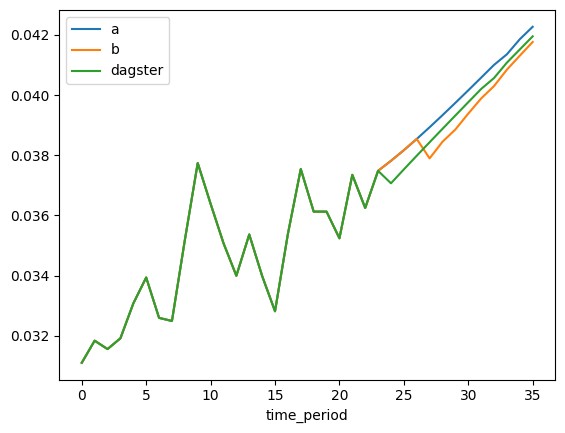

In [652]:
out_map["fast"][sequestration_columns].sum(axis=1).abs().plot(label="a")
asd[sequestration_columns].sum(axis=1).abs().plot(label="b")
df_emissions_fast[sequestration_columns].sum(axis=1).abs().plot(label="dagster")
plt.legend()

In [663]:
for label in ["fast", "normal", "slow"]:
    out_map[label].to_csv(
        out_path / "small" / "forecast" / "emissions" / label / f"{ZONE}.csv",
    )

test_fast = out_map["fast"]
test_normal = out_map["normal"]
test_slow = out_map["slow"]

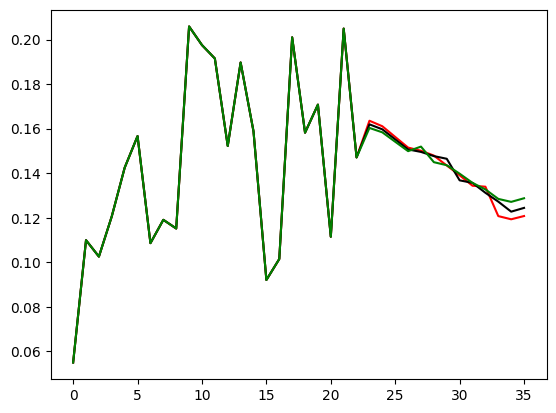

In [657]:
emission_fast = test_fast[emission_columns].sum(axis=1)
emission_normal = test_normal[emission_columns].sum(axis=1)
emission_slow = test_slow[emission_columns].sum(axis=1)

plt.plot(emission_fast, c="r")
plt.plot(emission_normal, c="k")
plt.plot(emission_slow, c="g")

<Axes: xlabel='time_period'>

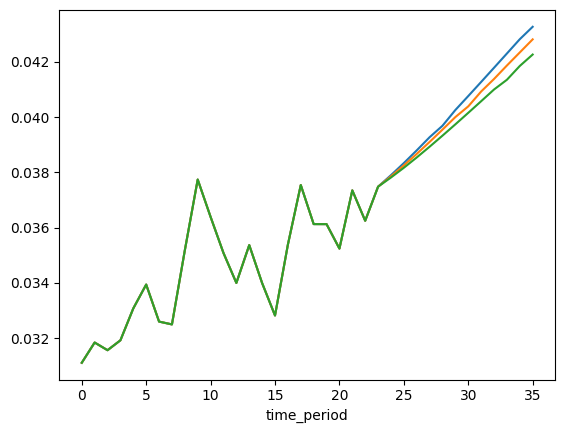

In [661]:
test_slow[sequestration_columns].sum(axis=1).abs().plot()
test_normal[sequestration_columns].sum(axis=1).abs().plot()
test_fast[sequestration_columns].sum(axis=1).abs().plot()

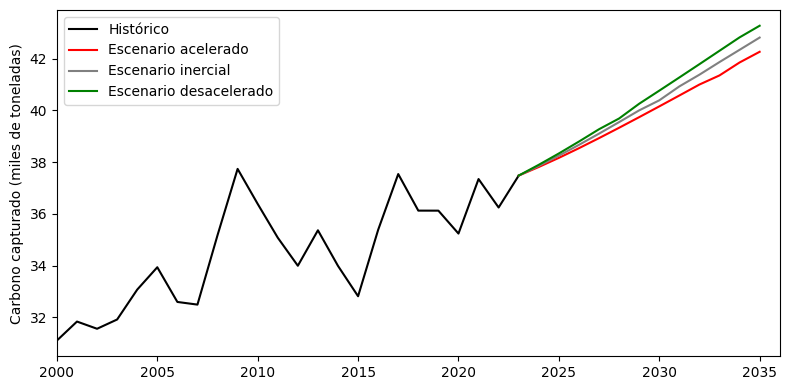

In [352]:
sequestration_fast = test_fast[sequestration_columns].sum(axis=1).abs().mul(1000)
sequestration_normal = test_normal[sequestration_columns].sum(axis=1).abs().mul(1000)
sequestration_slow = test_slow[sequestration_columns].sum(axis=1).abs().mul(1000)

idx = sequestration_slow.index + 2000

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(idx[:24], sequestration_fast[:24], c="k", label="Histórico")
ax.plot(idx[23:], sequestration_fast[23:], label="Escenario acelerado", c="r")
ax.plot(idx[23:], sequestration_normal[23:], label="Escenario inercial", c="gray")
ax.plot(idx[23:], sequestration_slow[23:], label="Escenario desacelerado", c="g")
ax.legend()

ax.set_xlim(2000, 2036)
# ax.set_ylim(55, 82)

ax.set_ylabel("Carbono capturado (miles de toneladas)")

fig.tight_layout()

In [21]:
(sequestration_slow - sequestration_normal).sum()

np.float64(3.4315097854297605)